## Data Cleaning

In [4]:
import numpy as np
import pandas as pd
!pip install matplotlib seaborn

You should consider upgrading via the 'c:\users\s8866\appdata\local\programs\python\python39\python.exe -m pip install --upgrade pip' command.


In [5]:
!pip install matplotlib seaborn

You should consider upgrading via the 'c:\users\s8866\appdata\local\programs\python\python39\python.exe -m pip install --upgrade pip' command.


In [8]:
#load the dataset
import seaborn as sns
import matplotlib.pyplot as plt
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [10]:
#descriptive statictics
#1.Numerical colms
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
#2. Categorical 

In [13]:
df.describe(include = "object")

,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [14]:
##Null vaues

In [15]:
#1. Count of missing values

In [16]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [18]:
missing_percent = (df.isnull().sum())/len(df)*100
missing_percent.sort_values(ascending = False)

deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
sex             0.000000
pclass          0.000000
survived        0.000000
fare            0.000000
parch           0.000000
sibsp           0.000000
class           0.000000
adult_male      0.000000
who             0.000000
alive           0.000000
alone           0.000000
dtype: float64

In [25]:
#filling the columns
#first check the distribution of age coln
#5% > replace
# 5-49% replace or remove
# 49% < remove


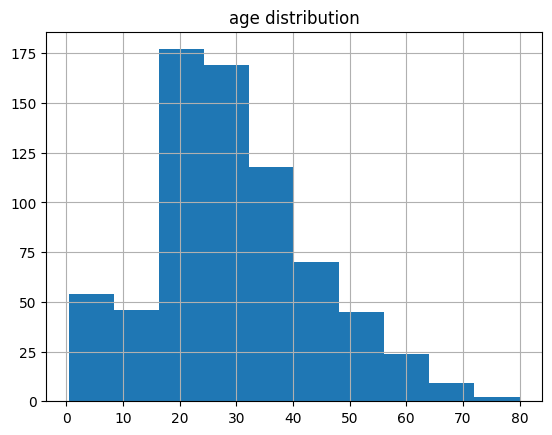

In [20]:
df["age"].hist()
plt.title("age distribution")
plt.show()

<Axes: xlabel='age', ylabel='Count'>

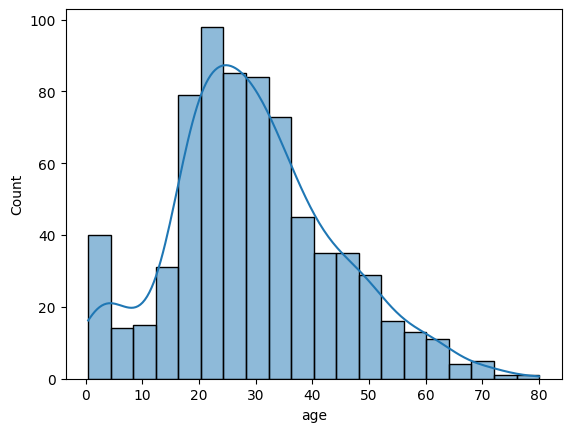

In [22]:
sns.histplot(data = df,x = "age",kde = True)

In [23]:
#the age column is skwewd so we replace with median

In [24]:
df["age"] = df["age"].fillna(df["age"].median())

In [26]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

In [27]:
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

In [29]:
# # symm -> mean
# skewed -> median
# categorical -> mode
# remove as nullvalue percentage > 50%

In [34]:
df.drop(columns = ["deck"], inplace = True)

KeyError: "['deck'] not found in axis"

In [32]:
#verify the null values
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [37]:
#duplicate values
print(df.duplicated().sum())

116


In [38]:
#dropping duplicate value

In [39]:
df = df.drop_duplicates()

In [40]:
#verify
print(df.duplicated().sum())

0


In [41]:
# datatypes

In [42]:
df.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
embark_town      object
alive            object
alone              bool
dtype: object

## Outliers

In [43]:
# we use boxplot to identify the outliers

<Axes: xlabel='fare'>

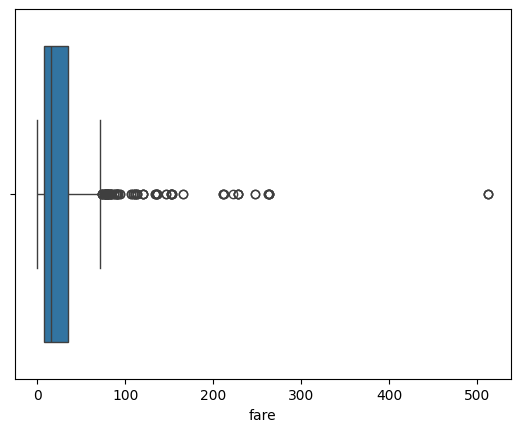

In [45]:
sns.boxplot(x = df["fare"])

In [46]:
#calculate TQR Bpundaries

In [54]:
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)
IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3 + 1.5*IQR

In [55]:
#remove the otliers
print("shape brfore removing outliers" ,df.shape)

df = df[(df["fare"] >= lower) & (df["fare"] <= upper)]

print("shape after removing outliers" ,df.shape)

shape brfore removing outliers (673, 14)
shape after removing outliers (643, 14)


<Axes: xlabel='fare'>

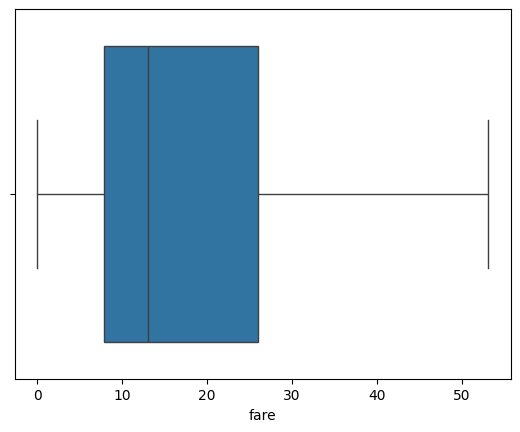

In [56]:
sns.boxplot(x = df["fare"])